# Class 5: Bike Share Demand Prediction


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import jinja2

prng = np.random.RandomState(20260304)

%precision 3
pd.set_option('display.precision', 3)
np.set_printoptions(suppress=True, precision=3)

sns.set_style('whitegrid')

## The Problem: Kaggle Bike Sharing Demand

Our goal is to predict hourly bike rental demand based on [this Kaggle competition](https://www.kaggle.com/c/bike-sharing-demand). The dataset contains:

- **Temporal**: datetime, season
- **Environmental**: weather, temperature, humidity, windspeed
- **Contextual**: holiday, working day
- **Target**: count of bike rentals

**Business context:** Bike sharing companies need to predict demand to:
- Ensure bikes are available where and when needed
- Optimize rebalancing operations
- Avoid stockouts (angry customers) and excess inventory (wasted resources)

<br>

---

*Question*: What metric to choose to evaluate our models?

<details>
<summary>Answer</summary>

Let's choose RMSLE (Root Mean Squared Log Error) because it
- is asymmetric: penalizes under-prediction more than over-prediction as it's better to have too many bikes than too few
- cares about relative errors: does not overly penalize predictions on high-demand periods while still valueing accuracy at low demand
- is easier to interpret: "we're 20% short" is more meaningful than "we're 40 bikes short"

Note that this is not what the algorithm directly minimizes during training. For those loss/optimization metrics, we haveve other requirements such as differentiability and smoothness to be computationally efficient.

</details>

---


## Setup & Baseline

### Load and explore the data



In [2]:
# Load data
bike_data = pd.read_csv(
    "https://raw.githubusercontent.com/divenyijanos/ceu-ml/2025/data/bike_sharing_demand/bike_sample.csv"
)

print(f"Dataset shape: {bike_data.shape}")
bike_data.head()

Dataset shape: (2177, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-10-18T03:00:00Z,4,0,1,1,18.04,21.970,94,6.003,0,1,1
1,2011-08-17T21:00:00Z,3,0,1,1,29.52,34.090,62,15.001,38,192,230
2,2012-11-11T11:00:00Z,4,0,0,1,18.86,22.725,59,8.998,180,324,504
3,2011-05-12T16:00:00Z,2,0,1,2,26.24,31.060,57,16.998,50,238,288
4,2011-05-04T15:00:00Z,2,0,1,1,19.68,23.485,51,27.999,22,107,129


In [3]:
bike_data.dtypes

datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

In [4]:
bike_data.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

### Train-test split for temporal data

<br>

---

*Question*: How should we split our data into training and test sets?

<details>
<summary>Answer</summary>

Recall that we want to mimic a real-world scenario where we deploy the model and it encounters future, unseen data.

For time series data, we cannot use random splitting. Random splitting would create *temporal leakage*: the model would learn from the future to predict the past, which artificially inflates performance.

To explicitly control for this, we will train on days 1-15 of each month and test on days 16+. 
⚠️ Note that this isn't perfect either as we still violate "future doesn't predict past" principle across months! However, we would like to match the Kaggle competition setup where test data is from the 20th onwards.

</details>

---

In [5]:
# Convert datetime and create temporal split
bike_data['datetime'] = pd.to_datetime(bike_data['datetime'])

# Days 1-15: train, Days 16+: test
train_indices = bike_data['datetime'].dt.day <= 15
test_indices = ~train_indices

# Initial features: only numeric columns (dropping datetime for now)
features = bike_data.drop(columns=['count', 'casual', 'registered']).select_dtypes(include=np.number)
label = bike_data['count']

X_train = features[train_indices]
X_test = features[test_indices]
y_train = label[train_indices]
y_test = label[test_indices]

print(f"Train size: {len(y_train)} ({len(y_train)/len(label):.1%})")
print(f"Test size: {len(y_test)} ({len(y_test)/len(label):.1%})")

Train size: 1735 (79.7%)
Test size: 442 (20.3%)


### Evaluation metric: RMSLE

**Root Mean Squared Log Error** is defined as:

$$
RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(\hat{y}_i + 1) - \log(y_i + 1))^2}
$$


*+1 to avoid log(0) when actual count is zero*

In [6]:
# Define RMSLE metric
def calculateRMSLE(prediction, y_obs):
    return np.sqrt(
        np.mean(
            (np.log(np.maximum(prediction, 0) + 1) - np.log(y_obs + 1))**2
        )
    )

### Helper class to track model performance

As we build many models, we need an organized way to compare them. This `ResultCollector` class stores all results and displays them as a formatted table with automatic improvement calculations.

In [7]:
# Helper class to track all models
class ResultCollector:
    def __init__(self):
        self.results = {}
        
    def add_model(self, name, train_error, test_error):
        """Add or update a model's results."""
        self.results[name] = {
            'Train RMSLE': train_error,
            'Test RMSLE': test_error,
            'Gap': test_error - train_error
        }
        return self.get_table()
    
    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        df['Improvement over Benchmark'] = df['Test RMSLE'].apply(
            lambda x: f"{round(100 * (df['Test RMSLE'].iloc[0] - x) / df['Test RMSLE'].iloc[0], 1)}%"
        )
        if style:
            return df.style.format("{:.3f}", subset=['Train RMSLE', 'Test RMSLE', 'Gap']).background_gradient(cmap='RdYlGn_r', subset=['Test RMSLE'], axis=None)
        return df

# Initialize results tracker
results = ResultCollector()

### Baseline model: Always have a benchmark

Before building complex models, establish a simple baseline. Here we'll predict the training mean for all test observations.

In [8]:
# Baseline: predict mean
baseline_pred = np.mean(y_train)

train_error = calculateRMSLE(np.full(len(y_train), baseline_pred), y_train)
test_error = calculateRMSLE(np.full(len(y_test), baseline_pred), y_test)

print(f"Baseline (mean): {baseline_pred:.1f} bikes")

results.add_model("Mean", train_error, test_error)

Baseline (mean): 194.4 bikes


,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,1.556,1.588,0.032,0.0%


#### Technical Detour: Pipeline and ColumnTransformer

In DA3, you learned to use `Pipeline` to chain transformations and models together. This ensures reproducibility: the same transformations apply to train and test.
For data manipulation, we can apply a similar trick with `ColumnTransformer`. It lets us apply different transformations to different columns *in parallel*:

```python
ColumnTransformer([
    ('name1', transformer1, columns1),
    ('name2', transformer2, columns2),
    ...
])
```

Each tuple contains:
1. **name**: You choose this (for identification)
2. **transformer**: The operation (e.g., `OneHotEncoder()`, `StandardScaler()`, `'passthrough'`)
3. **columns**: Which columns to apply it to (list of names or indices)

**Combining Pipeline + ColumnTransformer**

Since `ColumnTransformer` applies operations in parallel but we often need sequential steps (transform → model), we nest them in a `Pipeline`:

```python
pipe = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])),
    ('model', LinearRegression())
])
```

1. `ColumnTransformer` processes columns in parallel
2. Results are concatenated into one feature matrix
3. `LinearRegression` trains on the transformed features

Now let's use these tools!


## Linear Models

### Simple Linear Model

Let's build a linear model using the existing features
- **Categorical**: season, holiday, workingday, weather (need one-hot encoding)
- **Numeric**: temp, atemp, humidity, windspeed
- ⚠️ Note that `casual` and `registered` columns are not included to **avoid data leakage**

In [9]:
# Linear model with weather features
dummy_features = ['season', 'holiday', 'workingday', 'weather']
numeric_features = ['temp', 'atemp', 'humidity', 'windspeed']

# Pipeline: OneHotEncoder for categorical + LinearRegression
pipe_linear_weather = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features),
        ('num', 'passthrough', numeric_features)
    ])),
    ('model', LinearRegression())
])

pipe_linear_weather.fit(X_train, y_train)

train_error = calculateRMSLE(pipe_linear_weather.predict(X_train), y_train)
test_error = calculateRMSLE(pipe_linear_weather.predict(X_test), y_test)

results.add_model("Linear (weather)", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,1.556,1.588,0.032,0.0%
Linear (weather),1.383,1.431,0.048,9.9%


### Can we make linear models even more flexible?

Linear models assume relationships are... linear. But what if interactions matter? (e.g., temperature × hour) What if relations are non-linear? (e.g. quadratic)

*Polynomial features* let us create interactions and higher-order terms:
- $X_1, X_2 \rightarrow X_1, X_2, X_1^2, X_2^2, X_1 X_2, ...$

**Note:** We'll apply polynomial features to all features (including one-hot encoded categoricals). This creates many redundant features and leads to overfitting — which is exactly what we want to demonstrate! This is a teaching example, not a production approach.

In [10]:
# Polynomial OLS (degree=3) - very flexible!
pipe_poly_ols = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features),
        ('num', 'passthrough', numeric_features)
    ])),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

pipe_poly_ols.fit(X_train, y_train)

train_error = calculateRMSLE(pipe_poly_ols.predict(X_train), y_train)
test_error = calculateRMSLE(pipe_poly_ols.predict(X_test), y_test)

results.add_model("Polynomial OLS", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,1.556,1.588,0.032,0.0%
Linear (weather),1.383,1.431,0.048,9.9%
Polynomial OLS,1.261,1.815,0.554,-14.3%


**Overfitting detected!** Train error improved, but test error got worse.

This is **high variance**: the model is too flexible and memorizes training data instead of learning generalizable patterns.

**Why such extreme overfitting?** Applying polynomial features to one-hot encoded categories creates feature explosion:
- `season_winter² = season_winter` (redundant)
- `season_winter × season_spring = 0` (always zero, mutually exclusive)
- With degree=3 on all features, we created hundreds of mostly useless features

This demonstrates why unconstrained flexibility is dangerous!

### Regularization with Lasso

Recall: **Lasso** adds a penalty to constrain flexibility. By accepting some bias (shrinking coefficients), we could reduce variance.

In [11]:
# Polynomial Lasso (degree=3) - regularized!
pipe_poly_lasso = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features),
        ('num', StandardScaler(), numeric_features)  # Scale for Lasso
    ])),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LassoCV(random_state=prng, max_iter=10000))
])

pipe_poly_lasso.fit(X_train, y_train)

train_error = calculateRMSLE(pipe_poly_lasso.predict(X_train), y_train)
test_error = calculateRMSLE(pipe_poly_lasso.predict(X_test), y_test)

results.add_model("Polynomial Lasso", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,1.556,1.588,0.032,0.0%
Linear (weather),1.383,1.431,0.048,9.9%
Polynomial OLS,1.261,1.815,0.554,-14.3%
Polynomial Lasso,1.296,1.391,0.095,12.4%


**Regularization helps!** Test error improved by controlling overfitting. We added flexibility but controlled the complexity.

However, the performance gain is still relatively small. Let's investigate why.

### Diagnostics: What's going wrong?

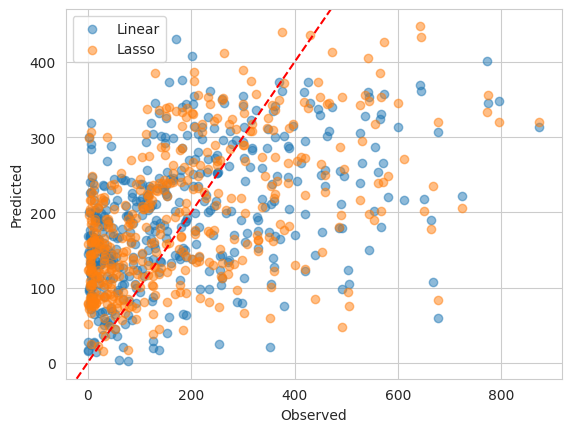

In [12]:
linear_predictions = pipe_linear_weather.predict(X_test)
lasso_predictions = pipe_poly_lasso.predict(X_test)

plt.scatter(y_test, linear_predictions, label='Linear', alpha=0.5)
plt.scatter(y_test, lasso_predictions, label='Lasso', alpha=0.5)
plt.axline((1, 1), slope=1, linestyle='dashed', color='red')
plt.xlabel('Observed')
plt.ylabel('Predicted')
plt.legend()

**Observation:** Our models consistently overestimate demand when actual count is low (points above diagonal line on the left side).

Let's investigate these low-demand cases:

In [13]:
bike_data[bike_data['count'] < 10]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-10-18 03:00:00+00:00,4,0,1,1,18.04,21.970,94,6.003,0,1,1
15,2012-09-12 03:00:00+00:00,3,0,1,1,20.50,24.240,77,6.003,0,7,7
16,2011-01-06 02:00:00+00:00,1,0,1,1,6.56,11.365,64,0.000,0,2,2
18,2011-01-04 00:00:00+00:00,1,0,1,1,6.56,9.090,55,7.002,0,5,5
24,2011-04-14 03:00:00+00:00,2,0,1,1,13.94,16.665,81,8.998,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
2114,2011-03-18 03:00:00+00:00,1,0,1,1,14.76,17.425,71,12.998,1,4,5
2123,2011-02-11 02:00:00+00:00,1,0,1,1,4.10,6.820,54,6.003,0,3,3
2158,2011-12-18 05:00:00+00:00,4,0,0,1,8.20,11.365,59,7.002,1,4,5
2160,2011-07-08 03:00:00+00:00,3,0,1,1,27.88,31.820,79,7.002,2,4,6


**Key Discovery:** Look at the `datetime` column! Low demand happens at night (00:00-05:00).

Our model doesn't know about time of day as we dropped the `datetime` column earlier!
The datetime column isn't just a timestamp but it encodes rich behavioral patterns!

</details>

## Improve Our Models

### Strategy #1: Feature Engineering

**Key insight:** Datetime contains structure! We can extract:
- **Hour** of day (rush hour vs late night)
- **Day of week** (weekday vs weekend)
- **Month** (seasonal patterns)
- **Year** (growth trends)

This is **feature engineering**: extracting information that's hidden in existing data.

In [14]:
# Function to extract datetime features
def extract_datetime_features(df):
    """Extract temporal features from datetime column."""
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    return df

# Apply feature engineering
bike_data_fe = extract_datetime_features(bike_data)

# Create new feature matrices
features_fe = bike_data_fe.drop(columns=['count', 'casual', 'registered']).select_dtypes(include=np.number)

X_train_fe = features_fe[train_indices]
X_test_fe = features_fe[test_indices]

print(f"Added: {X_train_fe.shape[1] - X_train.shape[1]} features")

Added: 4 features


In [15]:
# Linear model with feature engineering
dummy_features_fe = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'hour', 'dayofweek']

pipe_linear_fe = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features_fe),
        ('num', 'passthrough', numeric_features)
    ])),
    ('model', LinearRegression())
])

pipe_linear_fe.fit(X_train_fe, y_train)

train_error = calculateRMSLE(pipe_linear_fe.predict(X_train_fe), y_train)
test_error = calculateRMSLE(pipe_linear_fe.predict(X_test_fe), y_test)

results.add_model("Linear (FE)", train_error, test_error)

,Train RMSLE,Test RMSLE,Gap,Improvement over Benchmark
Mean,1.556,1.588,0.032,0.0%
Linear (weather),1.383,1.431,0.048,9.9%
Polynomial OLS,1.261,1.815,0.554,-14.3%
Polynomial Lasso,1.296,1.391,0.095,12.4%
Linear (FE),1.100,1.201,0.101,24.4%


In [ ]:
# Lasso model with feature engineering - takes a while...
pipe_lasso_fe = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features_fe),
        ('num', StandardScaler(), numeric_features)  # Scale for Lasso
    ])),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LassoCV(random_state=prng, max_iter=10000))
])

pipe_lasso_fe.fit(X_train_fe, y_train)

train_error = calculateRMSLE(pipe_lasso_fe.predict(X_train_fe), y_train)
test_error = calculateRMSLE(pipe_lasso_fe.predict(X_test_fe), y_test)

results.add_model("Polynomial Lasso (FE)", train_error, test_error)

We extracted information that was already in the data! Domain knowledge told us that time patterns matter for bike rentals.

Feature engineering reduces **bias** by allowing the model to capture patterns it couldn't see before.

### Strategy #2: More flexible models

Linear models assume straight-line relationships. But what if demand has complex patterns? Decision trees can capture:
- **Non-linear relationships** without manual polynomial features
- **Interactions automatically** (e.g., temperature matters differently at different hours)
- **Conditional logic** (if hour < 7 AND workingday = 1, then low demand)

Let's try a decision tree:

In [ ]:
# Decision Tree (shallow, max_depth=5)
tree_shallow = DecisionTreeRegressor(max_depth=5, random_state=prng)
tree_shallow.fit(X_train_fe, y_train)

train_error = calculateRMSLE(tree_shallow.predict(X_train_fe), y_train)
test_error = calculateRMSLE(tree_shallow.predict(X_test_fe), y_test)

results.add_model("Tree (depth=5)", train_error, test_error)

We got one of our best performances with much less computational burden!

In [ ]:
# Decision Tree (deep, max_depth=15)
tree_deep = DecisionTreeRegressor(max_depth=15, random_state=prng)
tree_deep.fit(X_train_fe, y_train)

train_error = calculateRMSLE(tree_deep.predict(X_train_fe), y_train)
test_error = calculateRMSLE(tree_deep.predict(X_test_fe), y_test)

results.add_model("Tree (depth=15)", train_error, test_error)

**Dramatic overfitting!** The deep tree memorizes training data. High variance strikes again. Complex models need constraints. Let's try a tree-based method that has built-in regularization (L1&L2, control on tree complexity, shrinkage, sampling, etc.)

In [ ]:
# XGBoost

# Helper function to convert categorical columns for XGBoost
def convert_to_category(X, cat_cols):
    """Convert specified columns to category dtype for XGBoost."""
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            X[col] = X[col].astype('category')
    return X

# Define categorical columns
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'hour', 'dayofweek']

# Create a pipeline for XGBoost
pipe_xgb = Pipeline([
    ('convert_cat', FunctionTransformer(
        lambda X: convert_to_category(X, cat_cols), 
        validate=False
    )),
    ('model', xgb.XGBRegressor(
        enable_categorical=True,
        random_state=prng,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    ))
])

# Hyperparameters:
# - n_estimators=100: number of trees (more trees = more complex, but also more training time)
# - max_depth=6: maximum tree depth (controls how complex each tree can be)
# - learning_rate=0.1: how much each tree contributes (lower = more conservative)
# These are reasonable starting values; in practice, you'd tune with cross-validation

pipe_xgb.fit(X_train_fe, y_train)

train_error = calculateRMSLE(pipe_xgb.predict(X_train_fe), y_train)
test_error = calculateRMSLE(pipe_xgb.predict(X_test_fe), y_test)

results.add_model("XGBoost (sample)", train_error, test_error)

XGBoost combines multiple techniques:
- **Ensemble:** Many weak models (trees) combine into a strong model
- **Boosting:** Each tree corrects errors from previous trees (sequential learning)
- **Regularization:** Built-in constraints (L1, L2, max_depth, min_child_weight) prevent overfitting

This is different from **Random Forest**, which uses:
- **Bagging:** Each tree is trained independently (parallel)
- **Averaging:** Reduces variance by averaging uncorrelated predictions

### Strategy #3: Collect More Data

Data collection is always an option to improve models. So far, we've been working with a sample of the available data. Let's see what happens when we use the full dataset.

**Before we look at results:** Which model type do you expect will benefit more from additional data?
- Simple models (linear) that are already stable?
- Flexible models (XGBoost) that might be suffering from high variance?

In [ ]:
# Load FULL dataset
bike_full = pd.read_csv(
    "https://raw.githubusercontent.com/divenyijanos/ceu-ml/2025/data/bike_sharing_demand/train.csv"
)

print("Dataset sizes:")
print(f"Sample (what we used): {len(bike_data):,} observations")
print(f"Full dataset: {len(bike_full):,} observations")
print(f"\nRatio: {len(bike_data)/len(bike_full):.1%}")

In [ ]:
# Prepare full dataset
bike_full_fe = extract_datetime_features(bike_full)

# Keep same test set for fair comparison!
# Only use days 1-15 from full data for training
train_indices_full = bike_full_fe['datetime'].dt.day <= 15

features_full = bike_full_fe.drop(columns=['count', 'casual', 'registered']).select_dtypes(include=np.number)
label_full = bike_full_fe['count']

X_train_full = features_full[train_indices_full]
y_train_full = label_full[train_indices_full]

print(f"Sample training set: {len(y_train):,} observations")
print(f"Full training set: {len(y_train_full):,} observations")
print(f"Increase: {len(y_train_full)/len(y_train):.1f}×")

Let's retrain our models on the full dataset to see which improves more.

In [ ]:
# Linear model on FULL data
pipe_linear_fe.fit(X_train_full, y_train_full)

train_error = calculateRMSLE(pipe_linear_fe.predict(X_train_full), y_train_full)
test_error = calculateRMSLE(pipe_linear_fe.predict(X_test_fe), y_test)

results.add_model("Linear (FE, FULL)", train_error, test_error)

**Connection to Class 4:** The linear model barely improved despite 5× more data. Remember the high-bias linear model in our Class 4 simulation? It plateaued regardless of sample size because it had systematic errors (high bias) that more data couldn't fix.

In [ ]:
# Tree (depth=5) on FULL data
tree_shallow.fit(X_train_full, y_train_full)

train_error = calculateRMSLE(tree_shallow.predict(X_train_full), y_train_full)
test_error = calculateRMSLE(tree_shallow.predict(X_test_fe), y_test)

results.add_model("Tree (depth=5, FULL)", train_error, test_error)

In [ ]:
# XGBoost on FULL data with Pipeline

# With more data, we can use a more complex model:
# - n_estimators=200 (doubled): more data supports more trees
# - max_depth=10 (increased): can learn deeper patterns with more observations
# - learning_rate=0.05 (halved): slower learning needs more trees but generalizes better
pipe_xgb_full = Pipeline([
    ('convert_cat', FunctionTransformer(
        lambda X: convert_to_category(X, cat_cols), 
        validate=False
    )),
    ('model', xgb.XGBRegressor(
        enable_categorical=True,
        random_state=prng,
        n_estimators=200,
        max_depth=10,
        learning_rate=0.05
    ))
])

pipe_xgb_full.fit(X_train_full, y_train_full)

train_error = calculateRMSLE(pipe_xgb_full.predict(X_train_full), y_train_full)
test_error = calculateRMSLE(pipe_xgb_full.predict(X_test_fe), y_test)

print("XGBoost with FULL data:")
print(f"Train RMSLE: {train_error:.2f}")
print(f"Test RMSLE: {test_error:.2f}")

results.add_model("XGBoost (FULL)", train_error, test_error)

**Connection to Class 4:** This is exactly what we saw with the quadratic model! Remember Class 4's simulation: when we increased data from n=100 to n=1000, the flexible quadratic model's test error dropped dramatically, while the linear model stayed flat. Here we see the same principle: XGBoost (low bias, high variance) benefits from more data by reducing variance, while the linear model (high bias, low variance) has already plateaued.

#### Visualize the impact

Let's create a side-by-side comparison showing how each model type benefits from more data.

In [ ]:
# Get actual results from our results table
results_df = results.get_table(style=False)

linear_sample = results_df.loc['Linear (FE)', 'Test RMSLE']
linear_full = results_df.loc['Linear (FE, FULL)', 'Test RMSLE']
tree_sample = results_df.loc['Tree (depth=5)', 'Test RMSLE']
tree_full = results_df.loc['Tree (depth=5, FULL)', 'Test RMSLE']
xgb_sample = results_df.loc['XGBoost (sample)', 'Test RMSLE']
xgb_full = results_df.loc['XGBoost (FULL)', 'Test RMSLE']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Create comparison for three models
models = ['Linear', 'Tree (depth=5)', 'XGBoost']
sample_scores = [linear_sample, tree_sample, xgb_sample]
full_scores = [linear_full, tree_full, xgb_full]

x = np.arange(len(models))
width = 0.35

# Left subplot: Sample vs Full for all models
bars1 = ax1.bar(x - width/2, sample_scores, width, label='Sample (20%)', color='lightcoral')
bars2 = ax1.bar(x + width/2, full_scores, width, label='Full (100%)', color='steelblue')

ax1.set_ylabel('Test RMSLE')
ax1.set_title('Model Performance: Sample vs Full Data')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.set_ylim([0, max(sample_scores) * 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Right subplot: Improvement from more data
improvements = [(sample_scores[i] - full_scores[i]) / sample_scores[i] * 100 
                for i in range(len(models))]
colors = ['coral' if imp > 0 else 'lightgray' for imp in improvements]
bars = ax2.bar(models, improvements, color=colors)

ax2.set_ylabel('Improvement (%)')
ax2.set_title('Benefit from More Data')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylim([0, max(improvements) * 1.2])

# Add value labels
for i, (bar, imp) in enumerate(zip(bars, improvements)):
    ax2.text(bar.get_x() + bar.get_width()/2., imp + 0.2,
            f'{imp:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Bias variance trade-off:
- **High bias models** (linear) plateau early — more data can't fix systematic errors
- **High variance models** (XGBoost) benefit dramatically — more data reduces sensitivity to noise

This validates the theory we saw in Class 4: flexible models need data to stabilize!

#### When Would More Data NOT Help?

While data collection is powerful, it's not always the answer:

**Scenario 1: Missing critical features (high bias)**
- If we never extracted `hour` from datetime, even 10× more data wouldn't help much
- **Lesson:** Fix bias problems (add better features) before collecting more data
- More data won't help if your model can't capture the underlying patterns

**Scenario 2: Already have enough data for model complexity**
- Linear model: 1.20 → 1.18 (minimal improvement with 5× more data)
- **Lesson:** Simple models plateau early; they don't need massive datasets
- Don't waste resources collecting data if your model is already stable

**Scenario 3: Diminishing returns**
- Going from 100 → 1,000 samples helps more than 10,000 → 11,000 samples
- **Lesson:** The first observations are most valuable
- Consider if data collection cost justifies marginal accuracy gains

**Bottom line:** More data is most valuable for flexible models suffering from high variance. Always try feature engineering first!

### Three Ways to Improve Models

| Strategy | What it does | When most helpful | Bias-variance trade-off |
|----------|--------------|-------------------|-------------------|
| **1. Feature Engineering** | Extract hidden information | Always! Helps all models | Reduces bias |
| **2. Model Flexibility** | Capture complex patterns | When patterns are non-linear | Reduces bias, increases variance |
| **3. Collect More Data** | Reduce variance | For flexible models | Reduces variance |


## Kaggle Submission

Let's complete the workflow by generating predictions for Kaggle's test set.

**Note:** The test set has no labels. We submit predictions to Kaggle and they evaluate on their hidden labels.

In [ ]:
# Load Kaggle test set
bike_test = pd.read_csv(
    "https://raw.githubusercontent.com/divenyijanos/ceu-ml/2025/data/bike_sharing_demand/test.csv"
)

print(f"Kaggle test set: {len(bike_test)} observations")
print("\nColumns:")
print(bike_test.columns.tolist())

In [ ]:
# Apply same feature engineering to Kaggle test set
bike_test_fe = extract_datetime_features(bike_test)
X_test_kaggle = bike_test_fe.drop(columns=['datetime']).select_dtypes(include=np.number)

# Note: Pipeline will handle categorical conversion automatically

In [ ]:
# Generate predictions with best model (XGBoost pipeline on full data)
predictions = pipe_xgb_full.predict(X_test_kaggle)

# Create submission file
submission = pd.DataFrame({
    'datetime': bike_test['datetime'],
    'count': predictions
})

print("Submission DataFrame created")
print("\nFirst few predictions:")
print(submission.head(10))

To submit to Kaggle:
1. Save: `submission.to_csv('submission.csv', index=False)`
2. Go to [Kaggle competition page](https://www.kaggle.com/c/bike-sharing-demand)
3. Upload CSV and get RMSLE score
4. Compare to leaderboard



## Bonus: Neural Network (MLP) — Preview of Class 6

So far we've used linear models and tree-based methods. Let's try a **Multi-Layer Perceptron (MLP)** — the simplest type of neural network.

An MLP works by passing inputs through layers of interconnected "neurons", each applying a weighted sum followed by a non-linear activation function. It learns by iteratively adjusting these weights to minimize a loss function (backpropagation + gradient descent).

**Key difference from trees:** Neural networks require **feature scaling**! Unlike decision trees (which only care about split ordering), gradient-based optimization is sensitive to feature magnitudes. We need to scale *all* features — including the one-hot encoded categoricals.

In [ ]:
# Neural Network (MLP) on FULL data
pipe_mlp = Pipeline([
    ('features', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False), dummy_features_fe),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('scaler', StandardScaler()),  # Scale ALL features (critical for neural networks!)
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=prng,
    ))
])

pipe_mlp.fit(X_train_full, y_train_full)

train_error = calculateRMSLE(pipe_mlp.predict(X_train_full), y_train_full)
test_error = calculateRMSLE(pipe_mlp.predict(X_test_fe), y_test)

print(f"Epochs trained: {pipe_mlp.named_steps['model'].n_iter_}")

results.add_model("Neural Network (MLP)", train_error, test_error)

**Observations:**
- The MLP is competitive but doesn't beat XGBoost on this tabular dataset — this is typical! Tree-based methods (XGBoost, Random Forest) tend to dominate on structured/tabular data.
- Neural networks require more careful preprocessing (scaling) and tuning (architecture, learning rate, epochs).

**So when do neural networks shine?** On **unstructured data** — images, text, audio, video — where they can learn hierarchical representations that no hand-crafted features can match. 

We'll explore neural networks more deeply in **Class 6**!

---

## Key Takeaways

1. **Always start with feature engineering** — biggest impact with least cost
2. **Watch the train-test gap** — your early warning system for overfitting
3. **Use regularization with flexible models** — Lasso, XGBoost, or cross-validation
4. **More data helps flexible models more** — validates Class 4 theory
5. **Ensemble methods balance flexibility with stability** — XGBoost is industry standard for tabular data
6. **Bias-variance trade-off guides all decisions** — no free lunch!
7. **Neural networks are powerful but not always best** — for tabular data, tree-based methods often win; NNs excel on images, text, and audio (more in Class 6!)